In [1]:
import ee
import geemap
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inicializa o Earth Engine com o projeto Cloud.
ee.Initialize(project='meumapbiomas')

# Define a pasta do projeto para salvar os arquivos de saída.
pasta_projeto = r'D:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios'

print('Earth Engine inicializado.')
print(f'Pasta do projeto: {pasta_projeto}')
print()
print('Estratégia metodológica:')
print(' - Imagens Landsat 5 (1999-2009) para capturar reservatório cheio')
print(' - DEM Copernicus para topografia atual')
print(' - Dissertação Sampaio (2014) como referência das cotas')

d:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Earth Engine inicializado.
Pasta do projeto: D:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios

Estratégia metodológica:
 - Imagens Landsat 5 (1999-2009) para capturar reservatório cheio
 - DEM Copernicus para topografia atual
 - Dissertação Sampaio (2014) como referência das cotas


In [2]:
#Área de estudo, data de inicio e fim das imagens e limiar de nuvens para filtragem das imagens.

area_estudo = ee.Geometry.Polygon([
    [
        [-41.42189474110167, -3.491920885731219],
        [-41.40955158292310, -3.535845087175473],
        [-41.38936184027277, -3.529647429646166],
        [-41.40294154066685, -3.487566117209032]
    ]
])

data_inicio = '1999-01-01'
data_fim = '2009-05-01'
limiar_nuvens=10

# Carrega o DEM Copernicus recortado na área ampliada.
dem_estudo = (ee.ImageCollection('COPERNICUS/DEM/GLO30')
              .mosaic()
              .select('DEM')
              .clip(area_estudo))

# Estatísticas básicas.
area_km2 = area_estudo.area(maxError=1).divide(1e6).getInfo()
estatisticas_dem = dem_estudo.reduceRegion(
    reducer=ee.Reducer.minMax().combine(
        reducer2=ee.Reducer.mean(),
        sharedInputs=True
    ),
    geometry=area_estudo,
    scale=30,
    maxPixels=int(1e9)
).getInfo()

print('Área de estudo ampliada definida e DEM carregado.')
print(f'Tamanho da área: {area_km2:.2f} km²')
print(f'Cota mínima do DEM: {estatisticas_dem["DEM_min"]:.2f} m')
print(f'Cota máxima do DEM: {estatisticas_dem["DEM_max"]:.2f} m')
print(f'Cota média do DEM:  {estatisticas_dem["DEM_mean"]:.2f} m')

Área de estudo ampliada definida e DEM carregado.
Tamanho da área: 11.23 km²
Cota mínima do DEM: 161.52 m
Cota máxima do DEM: 428.47 m
Cota média do DEM:  260.05 m


In [3]:
# Coleção Landsat 5 Collection 2 Surface Reflectance.
# Período: entrada em operação da barragem (1999) até pouco antes do rompimento (maio 2009).
colecao_l5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
              .filterBounds(area_estudo)
              .filterDate(data_inicio, data_fim)
              .filter(ee.Filter.lt('CLOUD_COVER', limiar_nuvens)))

n_imagens = colecao_l5.size().getInfo()
print(f'Imagens Landsat 5 encontradas no período pré-rompimento: {n_imagens}')

# Lista as imagens com data e cobertura de nuvens.
def extrair_info(img):
    return ee.Feature(None, {
        'data': img.date().format('YYYY-MM-dd'),
        'cobertura_nuvens': img.get('CLOUD_COVER'),
        'id': img.id()
    })

lista_imagens = colecao_l5.map(extrair_info).getInfo()['features']

# Converte para DataFrame para visualização.
df_imagens = pd.DataFrame([f['properties'] for f in lista_imagens])
df_imagens['data'] = pd.to_datetime(df_imagens['data'])
df_imagens = df_imagens.sort_values('data').reset_index(drop=True)

print()
print('Primeiras 10 imagens encontradas:')
print(df_imagens.head(10).to_string(index=False))
print()
print('Últimas 10 imagens encontradas:')
print(df_imagens.tail(10).to_string(index=False))

Imagens Landsat 5 encontradas no período pré-rompimento: 74

Primeiras 10 imagens encontradas:
 cobertura_nuvens       data                   id
                8 1999-07-02 LT05_218063_19990702
                7 1999-08-03 LT05_218063_19990803
                0 1999-08-10 LT05_219062_19990810
                8 1999-09-27 LT05_219062_19990927
                9 1999-10-29 LT05_219062_19991029
                9 1999-11-07 LT05_218062_19991107
                9 1999-11-07 LT05_218063_19991107
                9 2000-01-26 LT05_218062_20000126
                4 2000-06-09 LT05_219062_20000609
                9 2000-07-04 LT05_218063_20000704

Últimas 10 imagens encontradas:
 cobertura_nuvens       data                   id
                3 2007-09-10 LT05_218062_20070910
                8 2007-09-17 LT05_219062_20070917
                4 2007-10-03 LT05_219062_20071003
                3 2008-02-08 LT05_219062_20080208
                9 2008-04-28 LT05_219062_20080428
                8 2008

In [4]:
def processar_landsat5(imagem):
    """
    Processa uma imagem Landsat 5 Collection 2 Level-2:
    - aplica fatores de escala de reflectância
    - mascara nuvens, sombras e neve via QA_PIXEL
    - calcula MNDWI
    - identifica pixels de água (MNDWI > 0)
    - calcula área total de água na área de estudo
    """
    # Banda de qualidade.
    qa = imagem.select('QA_PIXEL')
    
    # Bits da máscara de qualidade no Landsat C2:
    # bit 1: dilated cloud
    # bit 2: cirrus
    # bit 3: cloud
    # bit 4: cloud shadow
    # bit 5: snow
    mascara_nuvens = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )
    
    # Aplica fatores de escala às bandas ópticas.
    # Fórmula oficial: SR = DN * 0.0000275 - 0.2
    bandas_opticas = imagem.select('SR_B.').multiply(0.0000275).add(-0.2)
    
    # Aplica a máscara de nuvens à imagem processada.
    imagem_limpa = bandas_opticas.updateMask(mascara_nuvens)
    
    # Calcula MNDWI = (Green - SWIR1) / (Green + SWIR1)
    # Landsat 5: Green = SR_B2, SWIR1 = SR_B5
    mndwi = imagem_limpa.normalizedDifference(['SR_B2', 'SR_B5']).rename('MNDWI')
    
    # Identifica água: MNDWI > 0.
    agua = mndwi.gt(0)
    
    # Calcula a área de água em m².
    area_por_pixel = agua.multiply(ee.Image.pixelArea()).rename('area')
    soma_area = area_por_pixel.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=area_estudo,
        scale=30,
        maxPixels=int(1e9)
    )
    
    return imagem.set({
        'data': imagem.date().format('YYYY-MM-dd'),
        'area_agua_m2': soma_area.get('area'),
        'cobertura_nuvens': imagem.get('CLOUD_COVER')
    })

# Aplica o processamento à coleção.
print('Processando 74 imagens Landsat 5. Aguarde, pode demorar alguns minutos...')
colecao_processada = colecao_l5.map(processar_landsat5)

# Extrai os resultados como lista.
def extrair_features(img):
    return ee.Feature(None, {
        'data': img.get('data'),
        'area_agua_m2': img.get('area_agua_m2'),
        'cobertura_nuvens': img.get('cobertura_nuvens'),
        'id': img.id()
    })

lista_resultados = colecao_processada.map(extrair_features).getInfo()['features']

# Converte para DataFrame.
df_areas = pd.DataFrame([f['properties'] for f in lista_resultados])
df_areas['data'] = pd.to_datetime(df_areas['data'])
df_areas['area_agua_km2'] = df_areas['area_agua_m2'] / 1e6
df_areas = df_areas.sort_values('data').reset_index(drop=True)

# Remove linhas com área zero ou nan (imagens muito ruins).
df_areas_validas = df_areas[df_areas['area_agua_km2'] > 0.01].copy()

print(f'Imagens processadas: {len(df_areas)}')
print(f'Imagens válidas (área > 0.01 km²): {len(df_areas_validas)}')
print()

print('Top 10 imagens com maior área de água (reservatório mais cheio):')
top10 = df_areas_validas.nlargest(10, 'area_agua_km2')
print(top10[['data', 'area_agua_km2', 'cobertura_nuvens', 'id']].to_string(index=False))
print()

print('Estatísticas da série temporal:')
print(f'  Área máxima: {df_areas_validas["area_agua_km2"].max():.3f} km²')
print(f'  Área mediana: {df_areas_validas["area_agua_km2"].median():.3f} km²')
print(f'  Área mínima: {df_areas_validas["area_agua_km2"].min():.3f} km²')
print()
print('Para referência (dissertação):')
print('  Área bacia hidráulica na cota máxima (320 m): 2,880 km²')

Processando 74 imagens Landsat 5. Aguarde, pode demorar alguns minutos...
Imagens processadas: 74
Imagens válidas (área > 0.01 km²): 65

Top 10 imagens com maior área de água (reservatório mais cheio):
      data  area_agua_km2  cobertura_nuvens                   id
2008-07-17       1.823059                 8 LT05_219062_20080717
2008-08-02       1.696558                 5 LT05_219062_20080802
2004-11-04       1.595047                 2 LT05_218063_20041104
2004-09-24       1.532376                 5 LT05_219062_20040924
2004-09-01       1.516824                 9 LT05_218062_20040901
2003-07-20       1.460603                 8 LT05_219062_20030720
2006-08-06       1.437700                 0 LT05_218063_20060806
2006-08-06       1.435902                 0 LT05_218062_20060806
2006-08-13       1.422922                 5 LT05_219062_20060813
2008-11-22       1.411257                 5 LT05_219062_20081122

Estatísticas da série temporal:
  Área máxima: 1.823 km²
  Área mediana: 1.162 km²

In [5]:
# Visualiza a imagem com maior área observada.
data_max = '2008-07-17'

imagem_max = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
              .filterBounds(area_estudo)
              .filterDate('2008-07-17', '2008-07-18')
              .first())

# Aplica fatores de escala para visualização correta.
imagem_escalada = imagem_max.select('SR_B.').multiply(0.0000275).add(-0.2)

# Cria mapa.
meuMapa = geemap.Map()
meuMapa.centerObject(area_estudo, zoom=13)

# Camada 1: imagem cor real.
parametros_cor_real = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0.0,
    'max': 0.3
}
meuMapa.addLayer(imagem_escalada, parametros_cor_real, 'Landsat 5 cor real')

# Camada 2: classificação de água (MNDWI > 0).
mndwi = imagem_escalada.normalizedDifference(['SR_B2', 'SR_B5'])
agua = mndwi.gt(0).selfMask()
meuMapa.addLayer(agua, {'palette': ['cyan']}, 'Água classificada (MNDWI > 0)')

# Camada 3: área de estudo.
meuMapa.addLayer(area_estudo, {'color': 'red'}, 'Área de estudo')

print(f'Imagem de {data_max} (área classificada: 1,823 km²)')
print('Verifique:')
print(' - se a área em ciano corresponde ao espelho do reservatório')
print(' - se a extensão parece coerente com reservatório próximo do cheio')

meuMapa

Imagem de 2008-07-17 (área classificada: 1,823 km²)
Verifique:
 - se a área em ciano corresponde ao espelho do reservatório
 - se a extensão parece coerente com reservatório próximo do cheio


Map(center=[-3.5115625343920867, -41.405899075656315], controls=(WidgetControl(options=['position', 'transpare…

In [6]:
# Carrega a imagem com maior área observada (reservatório próximo do cheio).
imagem_max_historica = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
                        .filterBounds(area_estudo)
                        .filterDate('2008-07-17', '2008-07-18')
                        .first())

# Aplica fatores de escala.
imagem_escalada = imagem_max_historica.select('SR_B.').multiply(0.0000275).add(-0.2)

# Aplica máscara de nuvens.
qa = imagem_max_historica.select('QA_PIXEL')
mascara_nuvens = (
    qa.bitwiseAnd(1 << 1).eq(0)
    .And(qa.bitwiseAnd(1 << 2).eq(0))
    .And(qa.bitwiseAnd(1 << 3).eq(0))
    .And(qa.bitwiseAnd(1 << 4).eq(0))
    .And(qa.bitwiseAnd(1 << 5).eq(0))
)
imagem_limpa = imagem_escalada.updateMask(mascara_nuvens)

# Classificação de água via MNDWI.
mndwi = imagem_limpa.normalizedDifference(['SR_B2', 'SR_B5']).rename('MNDWI')
mascara_reservatorio_historico = mndwi.gt(0)

# Buffer espacial de 100 m sobre o reservatório histórico, para incluir
# margens que poderiam estar inundadas em cotas levemente superiores.
kernel_dilatacao = ee.Kernel.circle(radius=50, units='meters')
mascara_bacia = mascara_reservatorio_historico.focal_max(
    kernel=kernel_dilatacao,
    iterations=1
).unmask(0)

print('Máscara da bacia hidráulica criada.')
print('Baseada no reservatório histórico cheio (17 julho 2008).')
print('Buffer de 50m aplicado para captar margens próximas.')

# Visualiza para verificação.
meuMapa = geemap.Map()
meuMapa.centerObject(area_estudo, zoom=13)

parametros_dem = {
    'min': 150,
    'max': 400,
    'palette': ['darkblue', 'blue', 'cyan', 'green', 'yellow', 'orange', 'red']
}
meuMapa.addLayer(dem_estudo, parametros_dem, 'DEM Copernicus')

meuMapa.addLayer(
    mascara_reservatorio_historico.selfMask(),
    {'palette': ['darkblue']},
    'Reservatório histórico (jul/2008)'
)

meuMapa.addLayer(
    mascara_bacia.selfMask(),
    {'palette': ['cyan']},
    'Máscara da bacia'
)

meuMapa.addLayer(area_estudo, {'color': 'red'}, 'Área de estudo')

meuMapa

Máscara da bacia hidráulica criada.
Baseada no reservatório histórico cheio (17 julho 2008).
Buffer de 50m aplicado para captar margens próximas.


Map(center=[-3.5115625343920867, -41.405899075656315], controls=(WidgetControl(options=['position', 'transpare…

In [7]:
# Calcula estatísticas do DEM nos pixels do reservatório histórico cheio.
stats_reservatorio_dem = (
    dem_estudo
    .updateMask(mascara_reservatorio_historico)
    .reduceRegion(
        reducer=ee.Reducer.minMax().combine(
            reducer2=ee.Reducer.mean(),
            sharedInputs=True
        ),
        geometry=area_estudo,
        scale=30,
        maxPixels=int(1e9)
    )
    .getInfo()
)

cota_min_dem = stats_reservatorio_dem["DEM_min"]
cota_max_dem = stats_reservatorio_dem["DEM_max"]
cota_media_dem = stats_reservatorio_dem["DEM_mean"]

print('=== Validação empírica do offset do DEM ===')
print()
print('Cotas observadas no DEM Copernicus nos pixels do reservatório histórico:')
print(f'  Cota mínima: {cota_min_dem:.2f} m')
print(f'  Cota máxima: {cota_max_dem:.2f} m (representa o nível d\'água)')
print(f'  Cota média:  {cota_media_dem:.2f} m')
print()
print('Referências da dissertação (julho 2008):')
print('  Cota d\'água registrada em junho 2008: 314,00 m')
print('  Cota do sangradouro: 320,00 m')
print()

# O DEM representa a superfície d'água nesses pixels (não o leito submerso),
# então a cota máxima do DEM nos pixels classificados como água
# corresponde aproximadamente à cota do espelho d'água.
# Como em julho/2008 o nível estava próximo de 314 m...
cota_estimada_espelho = 314  # cota provável do espelho em jul/2008
offset_calculado = cota_estimada_espelho - cota_max_dem

print(f'Offset calculado: {offset_calculado:.2f} m')
print(f'(Diferença entre cota declarada na dissertação e cota observada no DEM,')
print(f' para a superfície d\'água da mesma data.)')
print()
print('Aplicando offset, as cotas do DEM seriam comparáveis ao referencial da dissertação.')

# Cria DEM corrigido com o offset.
OFFSET_REFERENCIAL = offset_calculado
dem_corrigido = dem_estudo.add(OFFSET_REFERENCIAL)

# Verifica estatísticas após correção.
stats_corrigido = dem_corrigido.reduceRegion(
    reducer=ee.Reducer.minMax().combine(
        reducer2=ee.Reducer.mean(),
        sharedInputs=True
    ),
    geometry=area_estudo,
    scale=30,
    maxPixels=int(1e9)
).getInfo()

print()
print('DEM corrigido (referencial da dissertação):')
print(f'  Cota mínima: {stats_corrigido["DEM_min"]:.2f} m')
print(f'  Cota máxima: {stats_corrigido["DEM_max"]:.2f} m')
print(f'  Cota média:  {stats_corrigido["DEM_mean"]:.2f} m')

=== Validação empírica do offset do DEM ===

Cotas observadas no DEM Copernicus nos pixels do reservatório histórico:
  Cota mínima: 175.98 m
  Cota máxima: 197.70 m (representa o nível d'água)
  Cota média:  183.57 m

Referências da dissertação (julho 2008):
  Cota d'água registrada em junho 2008: 314,00 m
  Cota do sangradouro: 320,00 m

Offset calculado: 116.30 m
(Diferença entre cota declarada na dissertação e cota observada no DEM,
 para a superfície d'água da mesma data.)

Aplicando offset, as cotas do DEM seriam comparáveis ao referencial da dissertação.

DEM corrigido (referencial da dissertação):
  Cota mínima: 277.82 m
  Cota máxima: 544.78 m
  Cota média:  376.35 m


In [8]:
# Parâmetros da simulação no referencial da dissertação.
cota_inicial = 280  # margem inferior em relação ao leito (285 m)
cota_final = 322    # margem superior em relação ao sangradouro (320 m)
passo_cota = 0.5    # incremento entre cotas

cotas_simulacao = np.arange(cota_inicial, cota_final + passo_cota, passo_cota)

print(f'Simulação da curva cota-área-volume')
print(f'  Cotas: {cota_inicial} a {cota_final} m, passo {passo_cota} m')
print(f'  Total de cotas: {len(cotas_simulacao)}')
print(f'  Referencial: cotas do DEM corrigidas com offset de +116,30 m')
print()

# Função que calcula área inundada em uma cota específica.
def calcular_area_inundada(cota_alvo):
    """
    Calcula a área (km²) que estaria inundada na cota alvo,
    considerando o DEM corrigido e a máscara da bacia hidráulica.
    """
    pixels_abaixo = dem_corrigido.lte(cota_alvo)
    pixels_inundados = pixels_abaixo.And(mascara_bacia)
    area_por_pixel = pixels_inundados.multiply(ee.Image.pixelArea())
    soma = area_por_pixel.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=area_estudo,
        scale=30,
        maxPixels=int(1e9)
    )
    area_m2 = soma.get('DEM').getInfo()
    if area_m2 is None:
        return 0.0
    return area_m2 / 1e6

# Loop principal: calcula área para cada cota.
print('Calculando áreas inundadas. Aguarde...')
areas_km2 = []
for i, cota in enumerate(cotas_simulacao):
    area = calcular_area_inundada(cota)
    areas_km2.append(area)
    if (i + 1) % 10 == 0 or i == len(cotas_simulacao) - 1:
        print(f'  Cota {cota:6.1f} m: área = {area:6.4f} km²  ({i+1}/{len(cotas_simulacao)})')

print()
print('Calculando volumes por integração trapezoidal...')

# Calcula volume acumulado.
volumes_hm3 = [0.0]
for i in range(1, len(cotas_simulacao)):
    delta_cota = cotas_simulacao[i] - cotas_simulacao[i-1]
    area_media = (areas_km2[i] + areas_km2[i-1]) / 2
    delta_volume = area_media * delta_cota
    volumes_hm3.append(volumes_hm3[i-1] + delta_volume)

# Monta DataFrame com a curva completa.
df_curva = pd.DataFrame({
    'cota_m': cotas_simulacao,
    'area_km2': areas_km2,
    'volume_hm3': volumes_hm3
})

# Mostra resumo da tabela.
print()
print('=== Resumo da tabela cota-área-volume ===')
print('(mostrando uma linha a cada 5 cotas para não poluir)')
print()
print(df_curva.iloc[::5].to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print()

# Salva CSV completo.
caminho_csv = os.path.join(pasta_projeto, 'curva_cota_area_volume_algodoes.csv')
df_curva.to_csv(caminho_csv, index=False)
print(f'Tabela completa salva em: {caminho_csv}')

Simulação da curva cota-área-volume
  Cotas: 280 a 322 m, passo 0.5 m
  Total de cotas: 85
  Referencial: cotas do DEM corrigidas com offset de +116,30 m

Calculando áreas inundadas. Aguarde...
  Cota  284.5 m: área = 0.0000 km²  (10/85)
  Cota  289.5 m: área = 0.0000 km²  (20/85)
  Cota  294.5 m: área = 0.4647 km²  (30/85)
  Cota  299.5 m: área = 0.9376 km²  (40/85)
  Cota  304.5 m: área = 1.4462 km²  (50/85)
  Cota  309.5 m: área = 1.8832 km²  (60/85)
  Cota  314.5 m: área = 2.2402 km²  (70/85)
  Cota  319.5 m: área = 2.3407 km²  (80/85)
  Cota  322.0 m: área = 2.3542 km²  (85/85)

Calculando volumes por integração trapezoidal...

=== Resumo da tabela cota-área-volume ===
(mostrando uma linha a cada 5 cotas para não poluir)

 cota_m  area_km2  volume_hm3
280.000     0.000       0.000
282.500     0.000       0.000
285.000     0.000       0.000
287.500     0.000       0.000
290.000     0.000       0.000
292.500     0.352       0.088
295.000     0.506       1.133
297.500     0.771      

=== Validação dos resultados ===

Cota 320 m (sangradouro, capacidade máxima de projeto):
  Simulação:   área 2.343 km²,  volume 41.934 hm³
  SAMPAIO (2014): área 2,880 km²,  volume 51,000 hm³
  Divergência: área -18.6%, volume -17.8%

Cota 314 m (registrada em junho 2008, referência da calibração):
  Simulação:           área 2.217 km²,  volume 28.113 hm³
  Observação Landsat 5 (17/jul/2008): 1,823 km²
  Divergência observação vs simulação: -17.8%

Cota 310,60 m (registrada em julho 2004):
  Simulação: área 1.930 km², volume 19.759 hm³

Gráfico salvo em: D:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\curva_cota_area_volume_algodoes.png


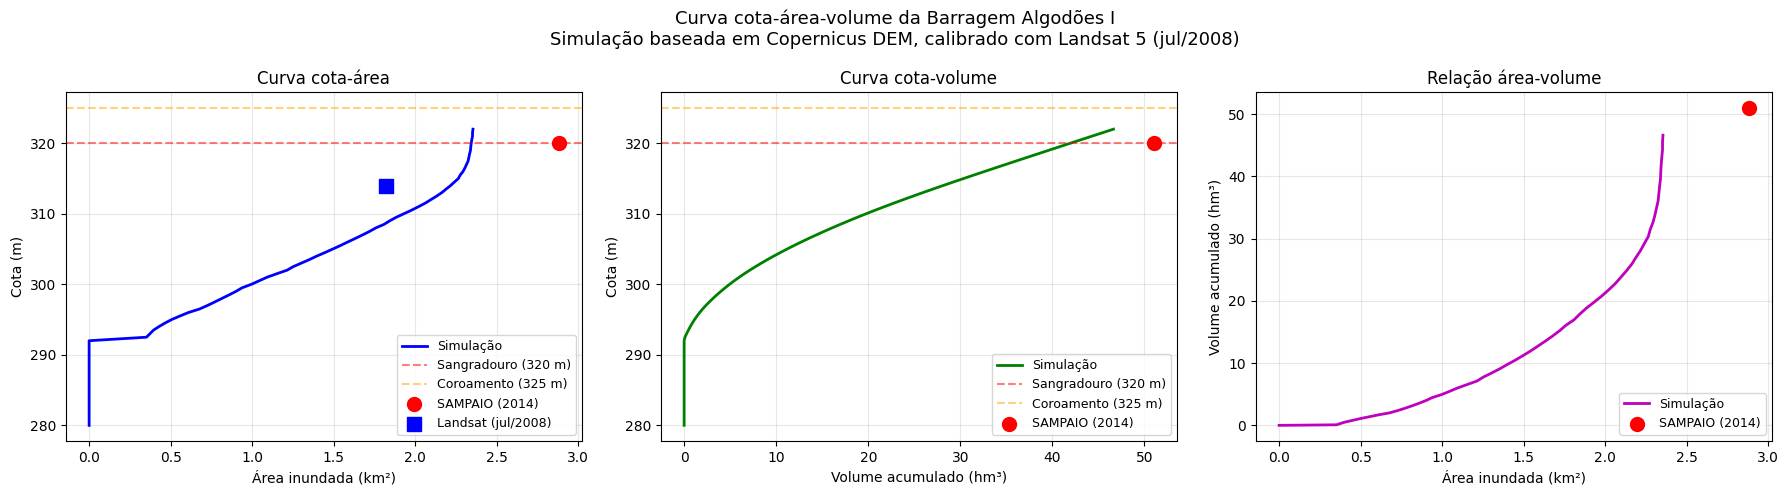

In [9]:
# Interpolação linear para obter valores em cotas específicas de interesse.
area_320 = np.interp(320, cotas_simulacao, areas_km2)
volume_320 = np.interp(320, cotas_simulacao, volumes_hm3)

area_314 = np.interp(314, cotas_simulacao, areas_km2)
volume_314 = np.interp(314, cotas_simulacao, volumes_hm3)

area_310 = np.interp(310, cotas_simulacao, areas_km2)
volume_310 = np.interp(310, cotas_simulacao, volumes_hm3)

print('=== Validação dos resultados ===\n')

print('Cota 320 m (sangradouro, capacidade máxima de projeto):')
print(f'  Simulação:   área {area_320:.3f} km²,  volume {volume_320:.3f} hm³')
print(f'  SAMPAIO (2014): área 2,880 km²,  volume 51,000 hm³')
if area_320 > 0:
    div_area_320 = ((area_320 - 2.88) / 2.88) * 100
    div_vol_320 = ((volume_320 - 51) / 51) * 100
    print(f'  Divergência: área {div_area_320:+.1f}%, volume {div_vol_320:+.1f}%')
print()

print('Cota 314 m (registrada em junho 2008, referência da calibração):')
print(f'  Simulação:           área {area_314:.3f} km²,  volume {volume_314:.3f} hm³')
print(f'  Observação Landsat 5 (17/jul/2008): 1,823 km²')
if area_314 > 0:
    div_area_314 = ((1.823 - area_314) / area_314) * 100
    print(f'  Divergência observação vs simulação: {div_area_314:+.1f}%')
print()

print('Cota 310,60 m (registrada em julho 2004):')
print(f'  Simulação: área {area_310:.3f} km², volume {volume_310:.3f} hm³')
print()

# Gera gráficos.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: cota versus área.
axes[0].plot(df_curva['area_km2'], df_curva['cota_m'], 'b-', linewidth=2, label='Simulação')
axes[0].axhline(y=320, color='red', linestyle='--', alpha=0.5, label='Sangradouro (320 m)')
axes[0].axhline(y=325, color='orange', linestyle='--', alpha=0.5, label='Coroamento (325 m)')
axes[0].scatter([2.88], [320], color='red', s=100, zorder=5, label='SAMPAIO (2014)')
axes[0].scatter([1.823], [314], color='blue', s=100, marker='s', zorder=5, label='Landsat (jul/2008)')
axes[0].set_xlabel('Área inundada (km²)')
axes[0].set_ylabel('Cota (m)')
axes[0].set_title('Curva cota-área')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: cota versus volume.
axes[1].plot(df_curva['volume_hm3'], df_curva['cota_m'], 'g-', linewidth=2, label='Simulação')
axes[1].axhline(y=320, color='red', linestyle='--', alpha=0.5, label='Sangradouro (320 m)')
axes[1].axhline(y=325, color='orange', linestyle='--', alpha=0.5, label='Coroamento (325 m)')
axes[1].scatter([51], [320], color='red', s=100, zorder=5, label='SAMPAIO (2014)')
axes[1].set_xlabel('Volume acumulado (hm³)')
axes[1].set_ylabel('Cota (m)')
axes[1].set_title('Curva cota-volume')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Gráfico 3: área versus volume.
axes[2].plot(df_curva['area_km2'], df_curva['volume_hm3'], 'm-', linewidth=2, label='Simulação')
axes[2].scatter([2.88], [51], color='red', s=100, zorder=5, label='SAMPAIO (2014)')
axes[2].set_xlabel('Área inundada (km²)')
axes[2].set_ylabel('Volume acumulado (hm³)')
axes[2].set_title('Relação área-volume')
axes[2].legend(loc='lower right', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'Curva cota-área-volume da Barragem Algodões I\n'
    'Simulação baseada em Copernicus DEM, calibrado com Landsat 5 (jul/2008)',
    fontsize=13
)
plt.tight_layout()

caminho_grafico = os.path.join(pasta_projeto, 'curva_cota_area_volume_algodoes.png')
plt.savefig(caminho_grafico, dpi=150, bbox_inches='tight')
print(f'Gráfico salvo em: {caminho_grafico}')

plt.show()

In [10]:

# 1. Defina a pasta onde deseja salvar a imagem (ex: pasta atual do projeto)
pasta_saida = os.path.join(os.getcwd(), 'imagens_baixadas')
os.makedirs(pasta_saida, exist_ok=True) # Cria a pasta se não existir

caminho_arquivo = os.path.join(pasta_saida, 'imagem_algodoes.tif')

# 2. Defina a imagem e a região (substitua pelas variáveis do seu código)
# Exemplo: 'imagem_final' é a sua imagem processada e 'roi' é o seu polígono/geometria
# 2. Defina a imagem e a região (substitua pelas variáveis do seu código)
imagem_para_baixar = imagem_limpa  # Use uma imagem já definida no notebook
regiao_interesse = area_estudo
# 1. Defina a pasta onde deseja salvar a imagem (ex: pasta atual do projeto)
pasta_saida = os.path.join(os.getcwd(), 'imagens_baixadas')
os.makedirs(pasta_saida, exist_ok=True)

caminho_arquivo = os.path.join(pasta_saida, 'imagem_algodoes.tif')

# 2. Defina a imagem e a região
imagem_para_baixar = imagem_limpa
regiao_interesse = area_estudo

# 3. Executa o download
print("Iniciando o download...")
geemap.ee_export_image(
    imagem_para_baixar,
    filename=caminho_arquivo,
    scale=30,
    region=regiao_interesse,
    file_per_band=False
)
print(f"Download concluído! Arquivo salvo em: {caminho_arquivo}")  # Substitua pelo nome da sua variável de geometria

# 3. Executa o download
print("Iniciando o download...")
geemap.ee_export_image(
    imagem_para_baixar,
    filename=caminho_arquivo,
    scale=30,          # Resolução espacial (30 metros para o Landsat)
    region=regiao_interesse,
    file_per_band=False # True se quiser um arquivo .tif para cada banda separada
)
print(f"Download concluído! Arquivo salvo em: {caminho_arquivo}")

Iniciando o download...
Generating URL ...
Please wait ...
Data downloaded to d:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\imagens_baixadas\imagem_algodoes.tif
Download concluído! Arquivo salvo em: d:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\imagens_baixadas\imagem_algodoes.tif
Iniciando o download...
Generating URL ...
Please wait ...
Data downloaded to d:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\imagens_baixadas\imagem_algodoes.tif
Download concluído! Arquivo salvo em: d:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\imagens_baixadas\imagem_algodoes.tif


Gráfico CAV combinado salvo em:
  D:\Documents\APOSTILAS\prof_aguas\curso\20261\hidrometricas\reservatorios\curva_cav_combinada_algodoes.png


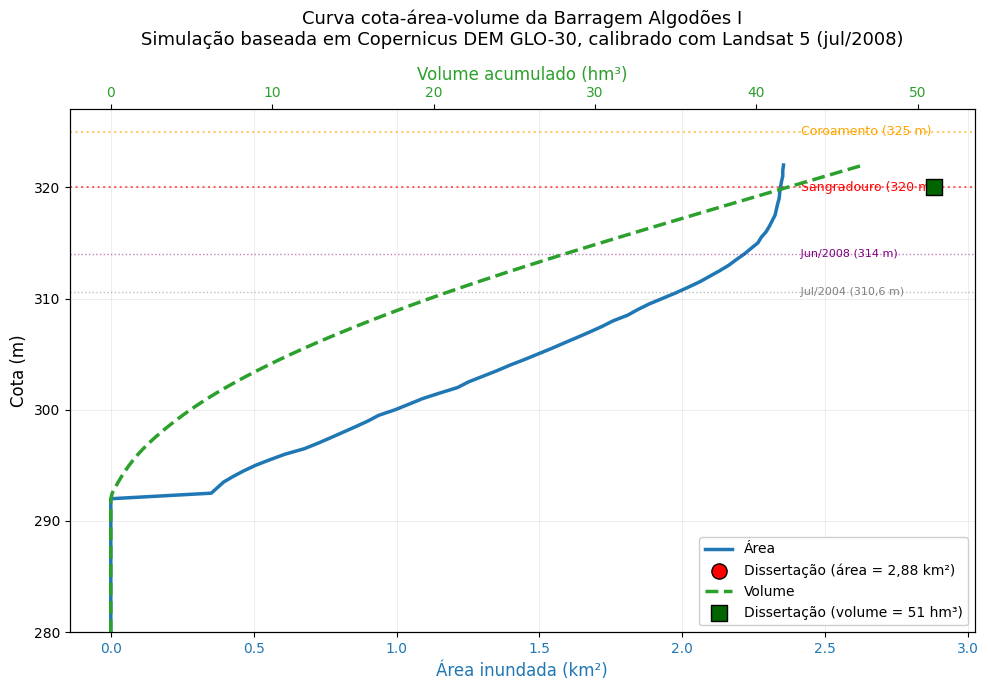

In [11]:
# Carrega a tabela cota-área-volume gerada anteriormente com Copernicus DEM.
caminho_csv = os.path.join(pasta_projeto, 'curva_cota_area_volume_algodoes.csv')
df_curva = pd.read_csv(caminho_csv)

# Cria figura com tamanho adequado para impressão em relatório.
fig, ax_area = plt.subplots(figsize=(10, 7))

# Eixo principal (esquerda): área no eixo X inferior, cota no eixo Y.
cor_area = 'tab:blue'
ax_area.plot(df_curva['area_km2'], df_curva['cota_m'],
             color=cor_area, linewidth=2.5, label='Área')
ax_area.set_xlabel('Área inundada (km²)', color=cor_area, fontsize=12)
ax_area.set_ylabel('Cota (m)', fontsize=12)
ax_area.tick_params(axis='x', labelcolor=cor_area)

# Segundo eixo X (superior): volume na mesma faixa vertical.
ax_volume = ax_area.twiny()
cor_volume = 'tab:green'
ax_volume.plot(df_curva['volume_hm3'], df_curva['cota_m'],
               color=cor_volume, linewidth=2.5, linestyle='--', label='Volume')
ax_volume.set_xlabel('Volume acumulado (hm³)', color=cor_volume, fontsize=12)
ax_volume.tick_params(axis='x', labelcolor=cor_volume)

# Linhas de referência horizontais nas cotas chave.
ax_area.axhline(y=320, color='red', linestyle=':', alpha=0.6, linewidth=1.5)
ax_area.axhline(y=325, color='orange', linestyle=':', alpha=0.6, linewidth=1.5)
ax_area.axhline(y=314, color='purple', linestyle=':', alpha=0.5, linewidth=1)
ax_area.axhline(y=310.60, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Anotações das cotas de referência (texto à direita do gráfico).
posicao_x_texto = df_curva['area_km2'].max() * 1.02
ax_area.text(posicao_x_texto, 325, ' Coroamento (325 m)',
             color='orange', fontsize=9, verticalalignment='center')
ax_area.text(posicao_x_texto, 320, ' Sangradouro (320 m)',
             color='red', fontsize=9, verticalalignment='center')
ax_area.text(posicao_x_texto, 314, ' Jun/2008 (314 m)',
             color='purple', fontsize=8, verticalalignment='center')
ax_area.text(posicao_x_texto, 310.60, ' Jul/2004 (310,6 m)',
             color='gray', fontsize=8, verticalalignment='center')

# Pontos de referência da dissertação.
ax_area.scatter([2.88], [320], color='red', s=120, zorder=10,
                marker='o', edgecolor='black', linewidth=1,
                label='Dissertação (área = 2,88 km²)')
ax_volume.scatter([51], [320], color='darkgreen', s=120, zorder=10,
                  marker='s', edgecolor='black', linewidth=1,
                  label='Dissertação (volume = 51 hm³)')

# Grade.
ax_area.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Limites do eixo Y para enquadrar bem.
ax_area.set_ylim(280, 327)

# Título.
plt.title(
    'Curva cota-área-volume da Barragem Algodões I\n'
    'Simulação baseada em Copernicus DEM GLO-30, calibrado com Landsat 5 (jul/2008)',
    fontsize=13, pad=15
)

# Legenda combinada de ambos os eixos.
linhas_area, labels_area = ax_area.get_legend_handles_labels()
linhas_vol, labels_vol = ax_volume.get_legend_handles_labels()
ax_area.legend(linhas_area + linhas_vol, labels_area + labels_vol,
               loc='lower right', fontsize=10, framealpha=0.95)

plt.tight_layout()

# Salva em arquivo.
caminho_grafico_cav = os.path.join(pasta_projeto, 'curva_cav_combinada_algodoes.png')
plt.savefig(caminho_grafico_cav, dpi=200, bbox_inches='tight')
print(f'Gráfico CAV combinado salvo em:')
print(f'  {caminho_grafico_cav}')

plt.show()